## 📊 Анализ на цените на горивата (2020 – 2026)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.dates as mdates

In [3]:
data = pd.read_csv('../datasets/fuelo_master_dataset.csv')
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year,start_date
0,1,30.12 - 05.01.20,1.14,1.17,0.49,2020,2020-12-30
1,2,06.01 - 12.01.20,1.14,1.17,0.49,2020,2020-01-06
2,3,13.01 - 19.01.20,1.14,1.17,0.49,2020,2020-01-13
3,4,20.01 - 26.01.20,1.14,1.17,0.50,2020,2020-01-20
4,5,27.01 - 02.02.20,1.14,1.17,0.50,2020,2020-01-27
...,...,...,...,...,...,...,...
316,4,19.01 - 25.01.26,1.24,1.26,0.59,2026,2026-01-19
317,5,26.01 - 01.02.26,1.24,1.26,0.57,2026,2026-01-26
318,6,02.02 - 08.02.26,1.24,1.26,0.58,2026,2026-02-02
319,7,09.02 - 15.02.26,1.24,1.26,0.58,2026,2026-02-09


In [4]:
data[["Бензин A95","Дизел", "Пропан Бутан"]].describe()

,Бензин A95,Дизел,Пропан Бутан
count,321.000000,321.000000,321.000000
mean,1.255701,1.284891,0.587819
std,0.198172,0.226390,0.098210
min,0.860000,0.880000,0.390000
25%,1.140000,1.160000,0.540000
50%,1.270000,1.270000,0.600000
75%,1.360000,1.410000,0.640000
max,1.750000,1.820000,0.820000


In [5]:
# data_for_excel = data[data['year'] == 2025]
# data_for_excel.to_excel("file.xlsx", index=False)

### Средна цена и статистически данни за 2024 година
##### mean - средна цена за годината
##### min - минимална цена
##### max - максимална цена

In [6]:
data[data['year'] == 2024].describe()

,№,Бензин A95,Дизел,Пропан Бутан,year
count,52.000000,52.000000,52.000000,52.000000,52.0
mean,26.500000,1.331154,1.343077,0.624423,2024.0
std,15.154757,0.039638,0.056135,0.022088,0.0
min,1.000000,1.270000,1.250000,0.590000,2024.0
25%,13.750000,1.290000,1.300000,0.600000,2024.0
50%,26.500000,1.340000,1.350000,0.630000,2024.0
75%,39.250000,1.360000,1.385000,0.640000,2024.0
max,52.000000,1.390000,1.430000,0.660000,2024.0


### Средна цена и статистически данни за 2025 година
##### mean - средна цена за годината
##### min - минимална цена
##### max - максимална цена

In [7]:
data[data['year'] == 2025].describe()

,№,Бензин A95,Дизел,Пропан Бутан,year
count,52.000000,52.000000,52.000000,52.000000,52.0
mean,26.500000,1.256731,1.264615,0.603654,2025.0
std,15.154757,0.043868,0.048768,0.044282,0.0
min,1.000000,1.200000,1.200000,0.550000,2025.0
25%,13.750000,1.230000,1.220000,0.560000,2025.0
50%,26.500000,1.240000,1.255000,0.585000,2025.0
75%,39.250000,1.300000,1.302500,0.660000,2025.0
max,52.000000,1.340000,1.360000,0.660000,2025.0


### 1️⃣ Колко е поскъпнал дизелът спрямо 2020 г.

Изчисляваме средната цена на дизела през 2020 г. и я сравняваме с текущата цена.
Това показва реалния процент на поскъпване за периода.

In [8]:
base_price = data[data["year"] == 2020]["Дизел"].mean()
current_price = data.iloc[-1]["Дизел"]

increase_pct = (current_price / base_price - 1) * 100

print(f"Дизелът е поскъпнал с {increase_pct:.1f}% спрямо 2020 г.")

Дизелът е поскъпнал с 29.3% спрямо 2020 г.


### 2️⃣ Най-скъпата седмица в периода

Откриваме седмицата с най-висока регистрирана цена на дизела.

👉 Това ни показва ценовия пик (най-скъпия момент за потребителите).

In [9]:
max_row = data.loc[data["Дизел"].idxmax()]

print("Най-скъпата седмица за дизела:")
print(max_row["Седмица"], "-", round(max_row["Дизел"], 2), "€")

Най-скъпата седмица за дизела:
27.06 - 03.07.22 - 1.82 €


### 3️⃣ Средна цена за текущата година

Изчисляваме средната цена за текущата година до момента.

👉 Позволява да сравним настоящата година с предходните.

In [10]:
current_year = data["year"].max()

avg_this_year = data[data["year"] == current_year][
    ["Бензин A95","Дизел","Пропан Бутан"]
].mean()

print(avg_this_year.round(2))

Бензин A95      1.30
Дизел           1.32
Пропан Бутан    0.61
dtype: float64


### 4️⃣ Колко струва пълен резервоар

Изчисляваме колко струва зареждане на 50 литра дизел при текущата цена.

👉 Това превежда цената в практическо измерение за шофьорите.

In [11]:
diesel_price = data.iloc[-1]["Дизел"]

tank_cost = diesel_price * 50

print(f"Пълен резервоар (50L дизел) струва {tank_cost:.2f} €")

Пълен резервоар (50L дизел) струва 63.00 €


### 5️⃣ Най-скъпата година

Изчисляваме средната цена по години и определяме коя година е била най-скъпа.

👉 Показва в коя година потребителите са плащали най-много средно.

In [12]:
yearly_avg = data.groupby("year")["Дизел"].mean()

most_expensive_year = yearly_avg.idxmax()

print("Най-скъпата година за дизела е:", most_expensive_year)

Най-скъпата година за дизела е: 2022


## 🚗 1️⃣ Колко струва горивото за една година

Изчисляваме приблизителен годишен разход при:

- 15 000 км годишно
- Разход: 7 л / 100 км
- Използваме средната цена за последната година

Това показва реалния годишен бюджет за гориво.

In [13]:
annual_km = 15000
consumption = 7  # литра на 100 км

current_year = data["year"].max()

avg_price = data[data["year"] == current_year]["Дизел"].mean()

liters_per_year = (annual_km / 100) * consumption
annual_cost = liters_per_year * avg_price

print(f"Годишен разход за гориво: {annual_cost:.2f} €")

Годишен разход за гориво: 1389.94 €


## ⛽ 2️⃣ Колко спестяваме с LPG вместо дизел

Сравняваме цената на 50 литра дизел и 50 литра пропан-бутан.

Това показва директната икономия при едно зареждане.

In [14]:
latest = data.iloc[-1]

diesel_cost = latest["Дизел"] * 50
lpg_cost = latest["Пропан Бутан"] * 50

savings = diesel_cost - lpg_cost

print(f"Икономия при 50L: {savings:.2f} €")

Икономия при 50L: 34.00 €


In [15]:
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year,start_date
0,1,30.12 - 05.01.20,1.14,1.17,0.49,2020,2020-12-30
1,2,06.01 - 12.01.20,1.14,1.17,0.49,2020,2020-01-06
2,3,13.01 - 19.01.20,1.14,1.17,0.49,2020,2020-01-13
3,4,20.01 - 26.01.20,1.14,1.17,0.50,2020,2020-01-20
4,5,27.01 - 02.02.20,1.14,1.17,0.50,2020,2020-01-27
...,...,...,...,...,...,...,...
316,4,19.01 - 25.01.26,1.24,1.26,0.59,2026,2026-01-19
317,5,26.01 - 01.02.26,1.24,1.26,0.57,2026,2026-01-26
318,6,02.02 - 08.02.26,1.24,1.26,0.58,2026,2026-02-02
319,7,09.02 - 15.02.26,1.24,1.26,0.58,2026,2026-02-09


In [20]:
data_2020_2025 = data[data['year'].isin([2020, 2021, 2022, 2023, 2024, 2025])]

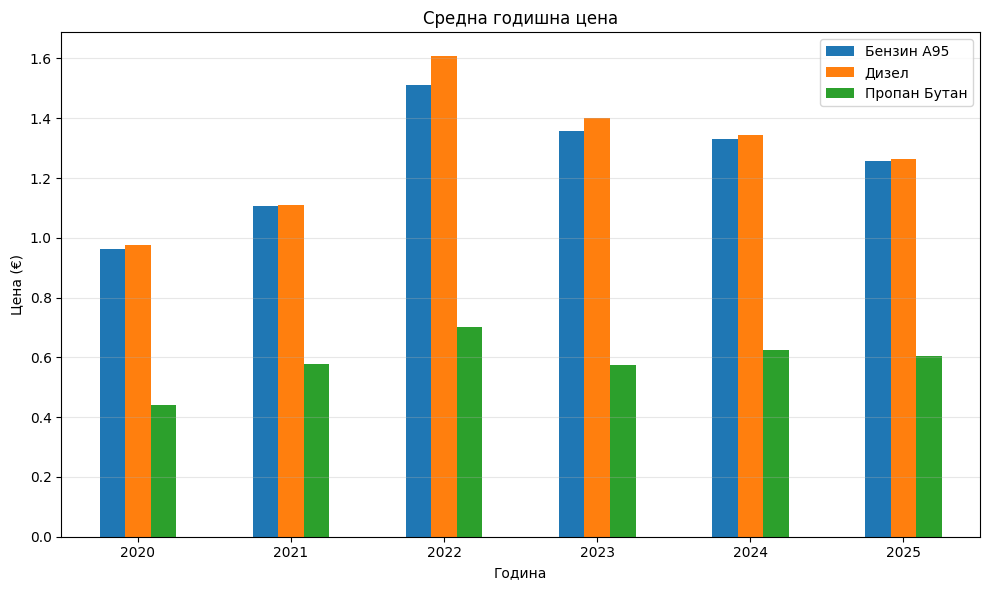

In [21]:
yearly_avg = data_2020_2025.groupby("year")[
    ["Бензин A95","Дизел","Пропан Бутан"]
].mean()

yearly_avg.plot(kind="bar", figsize=(10,6))

plt.title("Средна годишна цена")
plt.ylabel("Цена (€)")
plt.xlabel("Година")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

Графиката показва средните годишни цени на Бензин А95, Дизел и Пропан-бутан в България за периода 2020–2025 година. Данните ясно очертават силно покачване през 2022 г., последвано от постепенна стабилизация през следващите години.

През 2020 г. цените на горивата са на относително ниски нива, като Бензин А95 и Дизел се движат около 1.00 €/л, а Пропан-бутан – под 0.50 €/л. През 2021 г. се наблюдава умерено увеличение, което прераства в рязък ценови пик през 2022 г. Тогава средната цена на дизела достига около 1.60 €/л, а бензинът надхвърля 1.50 €/л – най-високите стойности за разглеждания период.

След 2022 г. пазарът започва корекция. През 2023–2025 г. цените постепенно се понижават и стабилизират, но остават по-високи спрямо нивата от 2020–2021 г. Пропан-бутанът следва сходна тенденция – пик през 2022 г., последван от умерен спад и стабилизиране около 0.60 €/л.

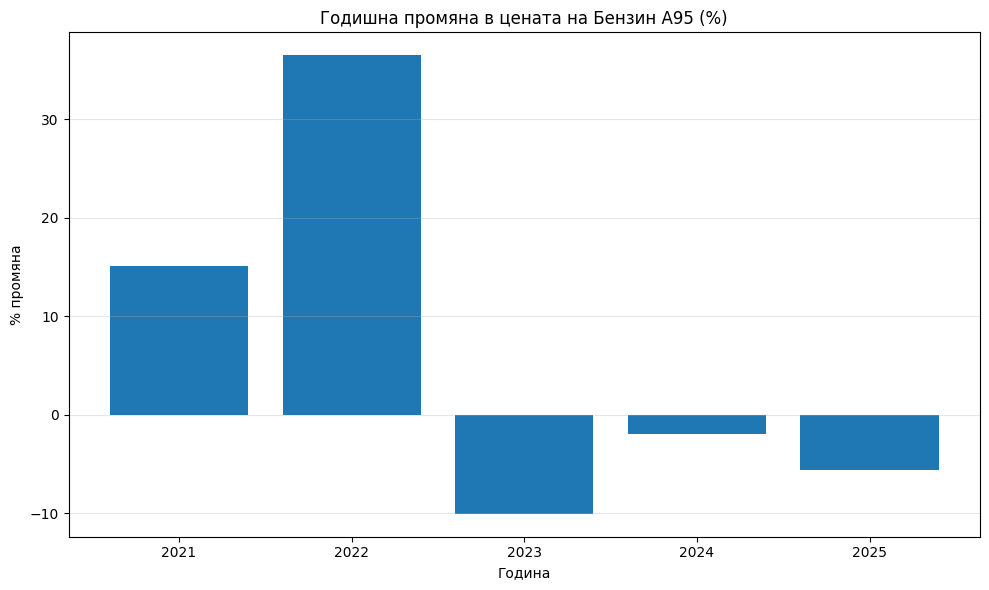

In [25]:
yearly_avg = data_2020_2025.groupby("year")["Бензин A95"].mean()
yoy = yearly_avg.pct_change() * 100

plt.figure(figsize=(10,6))
plt.bar(yoy.index, yoy.values)

plt.title("Годишна промяна в цената на Бензин А95 (%)")
plt.xlabel("Година")
plt.ylabel("% промяна")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

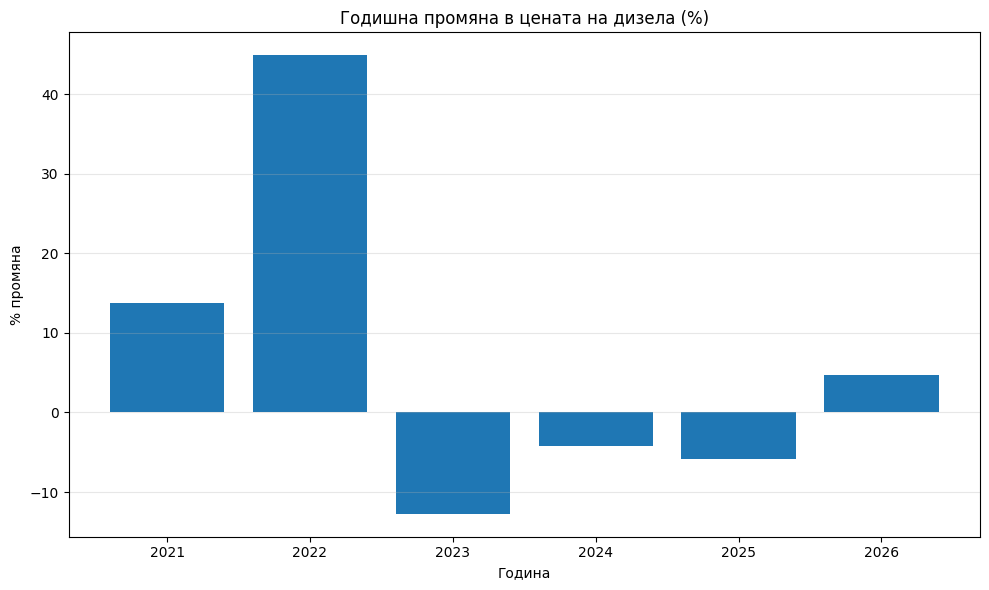

In [23]:
yearly_avg = data_2020_2025.groupby("year")["Дизел"].mean()
yoy = yearly_avg.pct_change() * 100

plt.figure(figsize=(10,6))
plt.bar(yoy.index, yoy.values)

plt.title("Годишна промяна в цената на дизела (%)")
plt.xlabel("Година")
plt.ylabel("% промяна")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

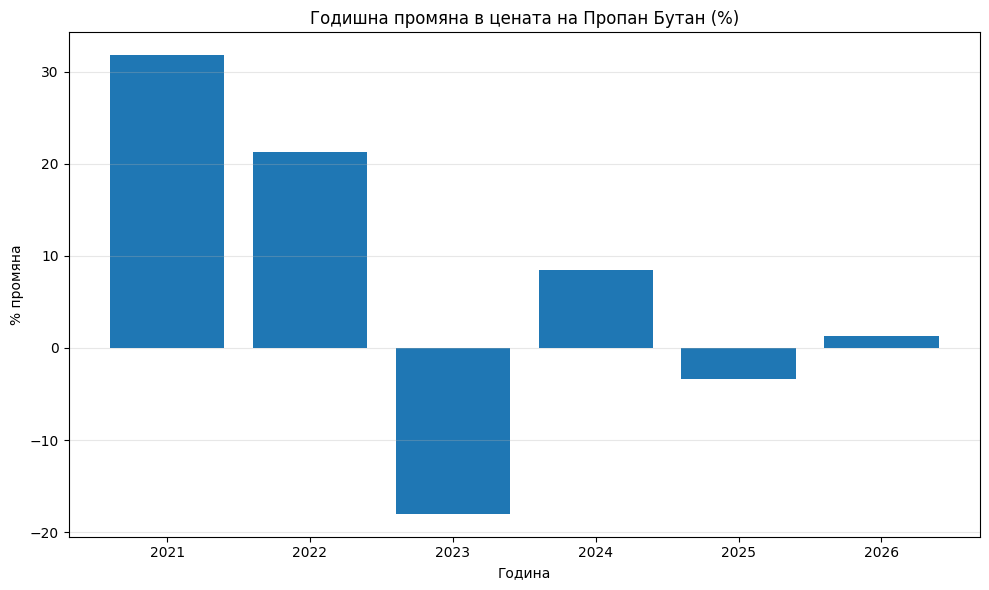

In [24]:
yearly_avg = data.groupby("year")["Пропан Бутан"].mean()
yoy = yearly_avg.pct_change() * 100

plt.figure(figsize=(10,6))
plt.bar(yoy.index, yoy.values)

plt.title("Годишна промяна в цената на Пропан Бутан (%)")
plt.xlabel("Година")
plt.ylabel("% промяна")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

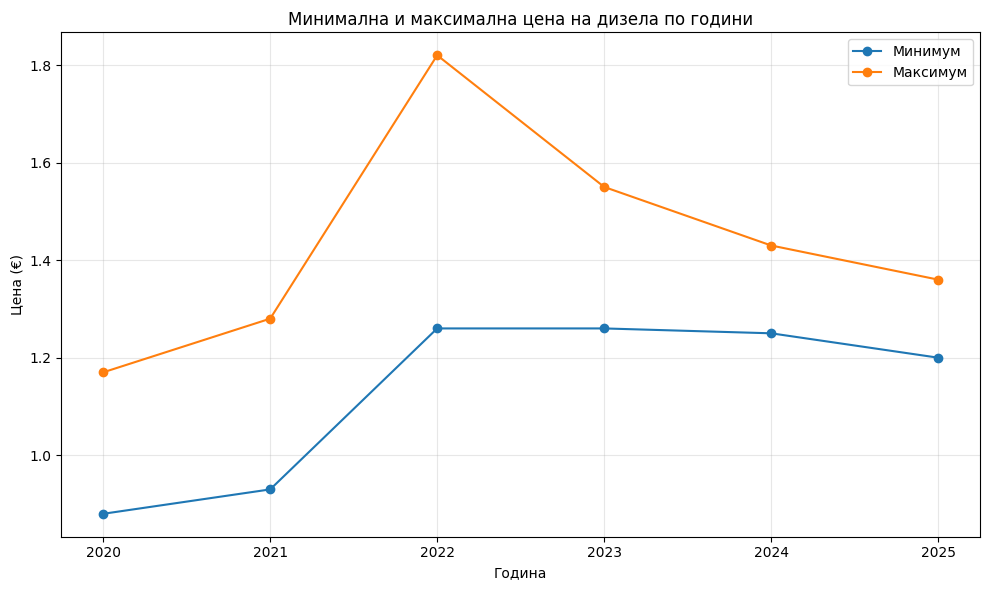

In [26]:
yearly_min = data_2020_2025.groupby("year")["Дизел"].min()
yearly_max = data_2020_2025.groupby("year")["Дизел"].max()

plt.figure(figsize=(10,6))

plt.plot(yearly_min.index, yearly_min.values, marker="o", label="Минимум")
plt.plot(yearly_max.index, yearly_max.values, marker="o", label="Максимум")

plt.title("Минимална и максимална цена на дизела по години")
plt.xlabel("Година")
plt.ylabel("Цена (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

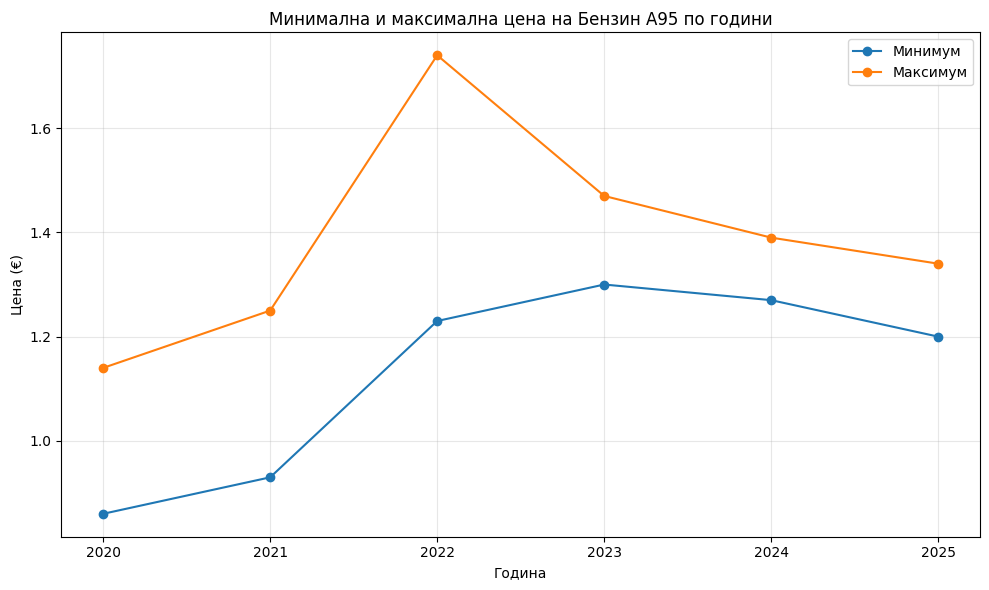

In [28]:
yearly_min = data_2020_2025.groupby("year")["Бензин A95"].min()
yearly_max = data_2020_2025.groupby("year")["Бензин A95"].max()

plt.figure(figsize=(10,6))

plt.plot(yearly_min.index, yearly_min.values, marker="o", label="Минимум")
plt.plot(yearly_max.index, yearly_max.values, marker="o", label="Максимум")

plt.title("Минимална и максимална цена на Бензин A95 по години")
plt.xlabel("Година")
plt.ylabel("Цена (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

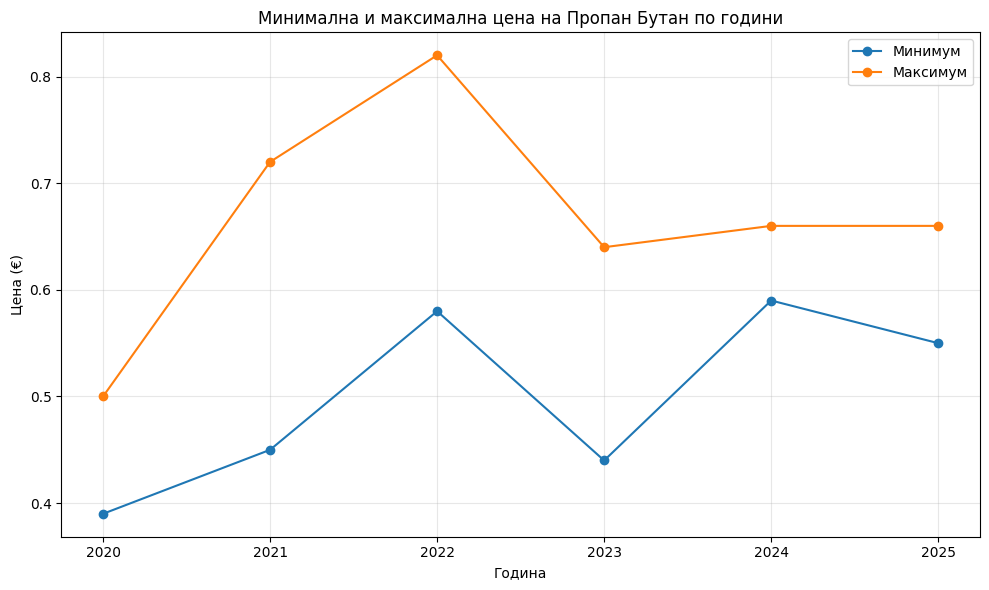

In [29]:
yearly_min = data_2020_2025.groupby("year")["Пропан Бутан"].min()
yearly_max = data_2020_2025.groupby("year")["Пропан Бутан"].max()

plt.figure(figsize=(10,6))

plt.plot(yearly_min.index, yearly_min.values, marker="o", label="Минимум")
plt.plot(yearly_max.index, yearly_max.values, marker="o", label="Максимум")

plt.title("Минимална и максимална цена на Пропан Бутан по години")
plt.xlabel("Година")
plt.ylabel("Цена (€)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year,start_date
0,1,30.12 - 05.01.20,1.14,1.17,0.49,2020,2020-12-30
1,2,06.01 - 12.01.20,1.14,1.17,0.49,2020,2020-01-06
2,3,13.01 - 19.01.20,1.14,1.17,0.49,2020,2020-01-13
3,4,20.01 - 26.01.20,1.14,1.17,0.50,2020,2020-01-20
4,5,27.01 - 02.02.20,1.14,1.17,0.50,2020,2020-01-27
...,...,...,...,...,...,...,...
316,4,19.01 - 25.01.26,1.24,1.26,0.59,2026,2026-01-19
317,5,26.01 - 01.02.26,1.24,1.26,0.57,2026,2026-01-26
318,6,02.02 - 08.02.26,1.24,1.26,0.58,2026,2026-02-02
319,7,09.02 - 15.02.26,1.24,1.26,0.58,2026,2026-02-09


In [31]:
data.columns

Index(['№', 'Седмица', 'Бензин A95', 'Дизел', 'Пропан Бутан', 'year',
       'start_date'],
      dtype='str')

In [32]:
def show_median_mean(product):
    stats = (
    data[data['year'].between(2020, 2026)]
    .groupby('year')[product]
    .agg(['mean', 'median'])
    .round(4)
)
    return stats

In [33]:
show_median_mean('Дизел')

,mean,median
year,,
2020,0.9746,0.920
2021,1.1092,1.095
2022,1.6071,1.670
2023,1.4025,1.420
2024,1.3431,1.350
2025,1.2646,1.255
2026,1.3238,1.260


In [34]:
show_median_mean('Бензин A95')

,mean,median
year,,
2020,0.9615,0.920
2021,1.1065,1.095
2022,1.5106,1.510
2023,1.3583,1.330
2024,1.3312,1.340
2025,1.2567,1.240
2026,1.3038,1.240


In [35]:
show_median_mean('Пропан Бутан')

,mean,median
year,,
2020,0.4390,0.430
2021,0.5787,0.555
2022,0.7021,0.710
2023,0.5757,0.600
2024,0.6244,0.630
2025,0.6037,0.585
2026,0.6112,0.580


In [36]:
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year,start_date
0,1,30.12 - 05.01.20,1.14,1.17,0.49,2020,2020-12-30
1,2,06.01 - 12.01.20,1.14,1.17,0.49,2020,2020-01-06
2,3,13.01 - 19.01.20,1.14,1.17,0.49,2020,2020-01-13
3,4,20.01 - 26.01.20,1.14,1.17,0.50,2020,2020-01-20
4,5,27.01 - 02.02.20,1.14,1.17,0.50,2020,2020-01-27
...,...,...,...,...,...,...,...
316,4,19.01 - 25.01.26,1.24,1.26,0.59,2026,2026-01-19
317,5,26.01 - 01.02.26,1.24,1.26,0.57,2026,2026-01-26
318,6,02.02 - 08.02.26,1.24,1.26,0.58,2026,2026-02-02
319,7,09.02 - 15.02.26,1.24,1.26,0.58,2026,2026-02-09


In [37]:
# уверяваме се, че датата е datetime
data['start_date'] = pd.to_datetime(data['start_date'])

# създаваме месец като номер
data['month'] = data['start_date'].dt.month

In [38]:
data

,№,Седмица,Бензин A95,Дизел,Пропан Бутан,year,start_date,month
0,1,30.12 - 05.01.20,1.14,1.17,0.49,2020,2020-12-30,12
1,2,06.01 - 12.01.20,1.14,1.17,0.49,2020,2020-01-06,1
2,3,13.01 - 19.01.20,1.14,1.17,0.49,2020,2020-01-13,1
3,4,20.01 - 26.01.20,1.14,1.17,0.50,2020,2020-01-20,1
4,5,27.01 - 02.02.20,1.14,1.17,0.50,2020,2020-01-27,1
...,...,...,...,...,...,...,...,...
316,4,19.01 - 25.01.26,1.24,1.26,0.59,2026,2026-01-19,1
317,5,26.01 - 01.02.26,1.24,1.26,0.57,2026,2026-01-26,1
318,6,02.02 - 08.02.26,1.24,1.26,0.58,2026,2026-02-02,2
319,7,09.02 - 15.02.26,1.24,1.26,0.58,2026,2026-02-09,2


In [39]:
def build_product_json(df, column_name, product_id, product_name, slug, image):

    result = {
        "id": product_id,
        "name": product_name,
        "prices": {},
        "slug": slug,
        "image": image
    }

    # групиране по година и месец
    monthly = (
        df
        .groupby(['year', 'month'])[column_name]
        .mean()
        .round(2)
        .reset_index()
    )

    # обхождаме по години
    for year in monthly['year'].unique():

        year_data = monthly[monthly['year'] == year]

        monthly_dict = {}

        for _, row in year_data.iterrows():
            month_key = pd.to_datetime(f"{year}-{int(row['month'])}-01").strftime('%b').lower()
            monthly_dict[month_key] = float(row[column_name])

        yearly_avg = round(year_data[column_name].mean(), 2)

        result["prices"][str(year)] = {
            "monthly": monthly_dict,
            "avg": yearly_avg
        }

    return result

In [40]:
data.columns

Index(['№', 'Седмица', 'Бензин A95', 'Дизел', 'Пропан Бутан', 'year',
       'start_date', 'month'],
      dtype='str')

In [41]:
products = []

products.append(
    build_product_json(data, "Бензин A95", 1, "Бензин A95", "benzin", "benzin.webp")
)

products.append(
    build_product_json(data, "Дизел", 2, "Дизел", "diesel", "diesel.webp")
)

products.append(
    build_product_json(data, "Пропан Бутан", 3, "Пропан Бутан", "propan-butan", "propan-butan.webp")
)

In [ ]:
# import json
#
# json_output = json.dumps(products, ensure_ascii=False, indent=2)
# print(json_output)

In [ ]:
# with open("fuel.json", "w", encoding="utf-8") as f:
#     json.dump(products, f, ensure_ascii=False, indent=2)